# Projet Data/IA - Analyse des matchs de football

## Chargement et aperçu des données

On charge le dataset `results.csv` avec Pandas, puis on affiche les 5 premières lignes pour voir la structure des données.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

df.head()




,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## Analyse 1 : Top 10 des équipes avec le plus de victoires

On filtre les matchs pour identifier les victoires à domicile et à l'extérieur. On compte ensuite le nombre total de victoires par équipe, on trie et on affiche les 10 meilleures avec un graphique en barres.

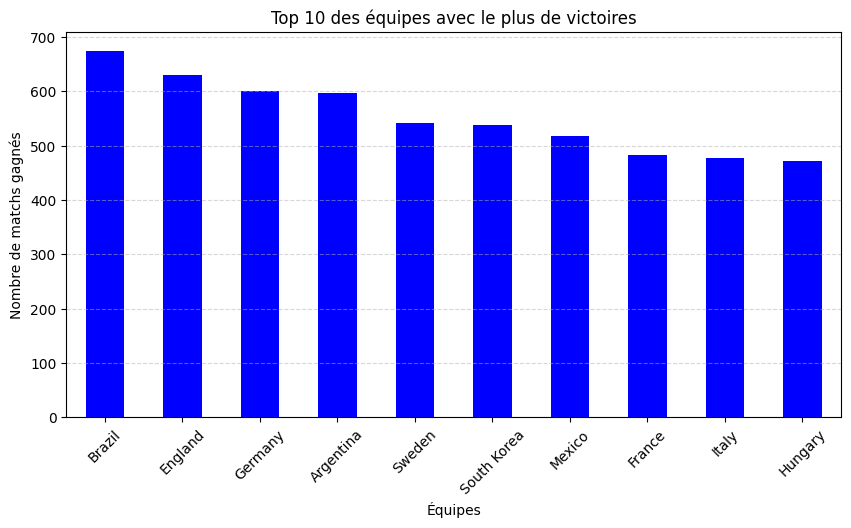

In [ ]:
#Quelles sont les 10 équipes qui ont gagné le plus de matchs ?
winners_home_teams = df[df['home_score'] > df['away_score']]
winners_away_teams = df[df['away_score'] > df['home_score']]
ht = winners_home_teams.groupby('home_team').size()
at = winners_away_teams.groupby('away_team').size()
res = pd.concat([at, ht]).groupby(level=0).sum()
top_10 = res.sort_values(ascending=False).head(10)
top_10.plot(kind='bar', color='blue', figsize=(10,5))


plt.title("Top 10 des équipes avec le plus de victoires")
plt.xlabel("Équipes")
plt.ylabel("Nombre de matchs gagnés")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Analyse 2 : Top 10 des équipes avec le plus de buts marqués

On calcule le total des buts marqués par chaque équipe à domicile et à l'extérieur. On additionne les deux totaux, on trie et on affiche les 10 meilleures équipes avec un graphique en barres.

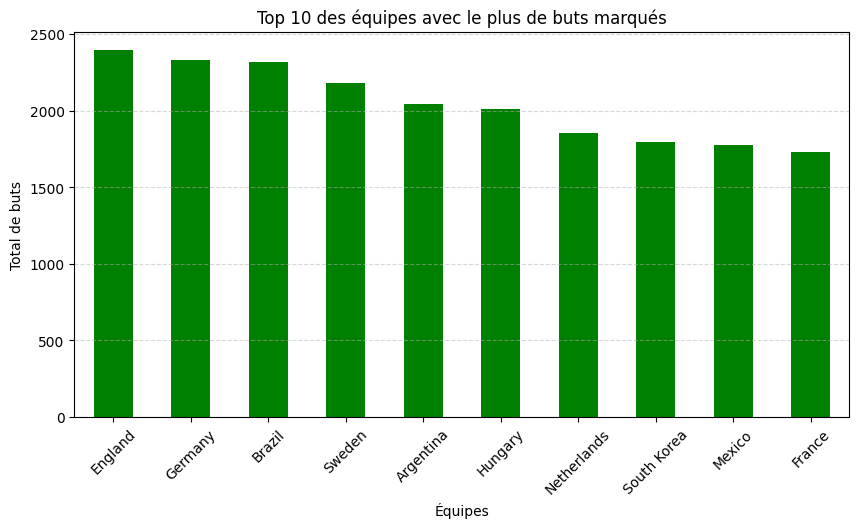

In [ ]:
# Quelles sont les 10 équipes qui ont marqué le plus de buts ?
home_goals = df.groupby('home_team')['home_score'].sum()
away_goals = df.groupby('away_team')['away_score'].sum()
res = pd.concat([home_goals,away_goals]).groupby(level=0).sum()
top_10_goals = res.sort_values(ascending = False).head(10)
top_10_goals.plot(kind='bar', color='green', figsize=(10,5))

plt.title("Top 10 des équipes avec le plus de buts marqués")
plt.xlabel("Équipes")
plt.ylabel("Total de buts")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Analyse 3 : Évolution du nombre de matchs joués par année

On extrait l'année de la colonne `date`, puis on compte le nombre de matchs joués chaque année. On trace ensuite une courbe d'évolution pour visualiser la tendance sur la période 1872-2017.

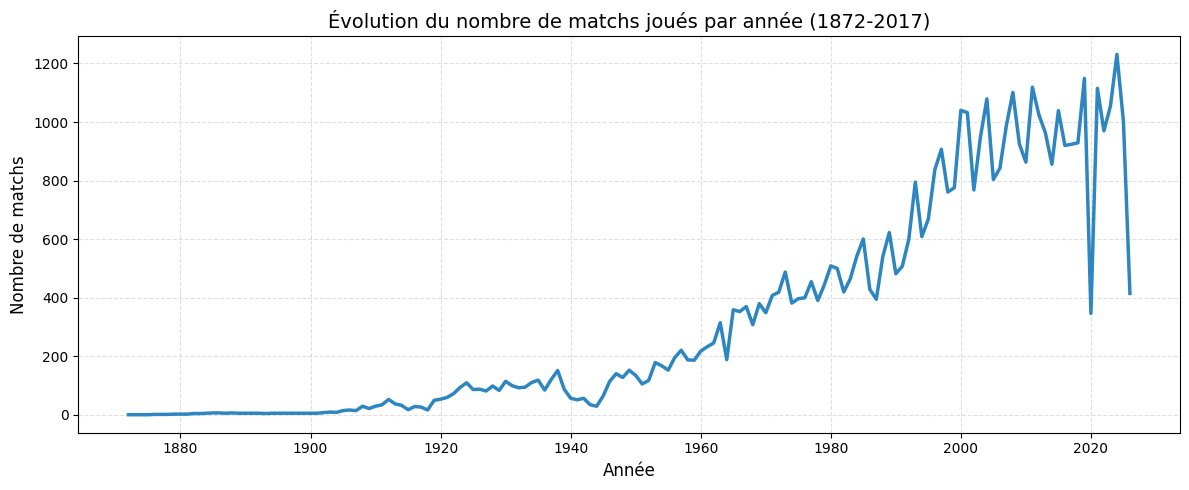

In [ ]:
# Évolution du nombre de matchs joués par année
df['annee'] = pd.to_datetime(df['date']).dt.year
res = df.groupby('annee').size()

res.plot( kind='line', color='#2E86C1', linewidth=2.5, figsize=(12,5))

plt.title("Évolution du nombre de matchs joués par année (1872-2017)", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre de matchs", fontsize=12)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Analyse 4 : Top 10 des compétitions avec le plus de matchs

On regroupe les matchs par compétition (`tournament`), on compte le nombre de matchs pour chaque compétition, puis on affiche les 10 compétitions les plus représentées avec un graphique en barres.

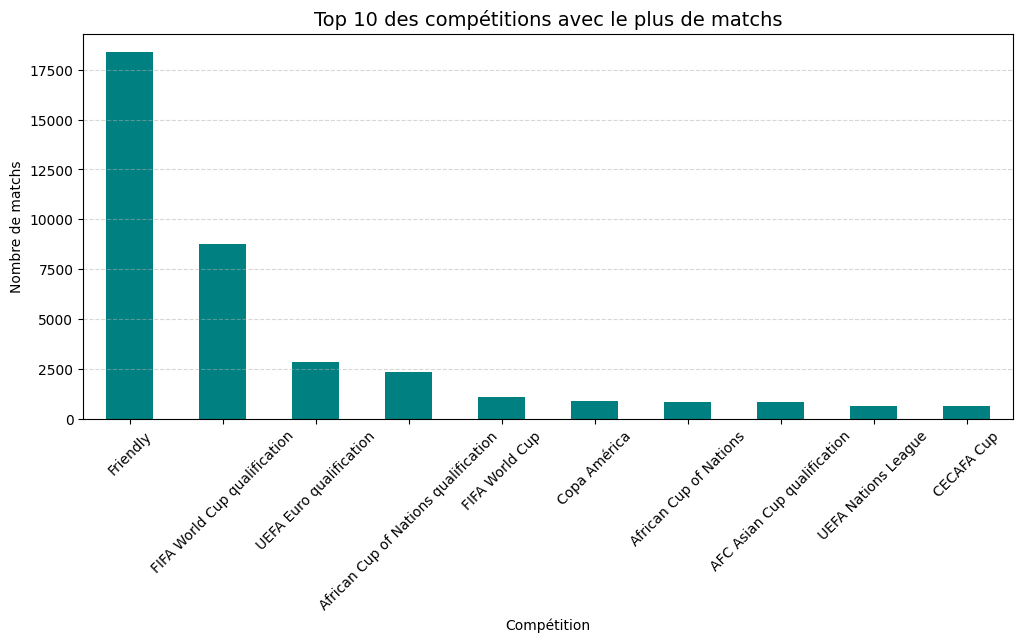

In [ ]:
# Question 4 : Quelle compétition a le plus de matchs ?
res = df.groupby('tournament').size()
top_10_competition = res.sort_values(ascending=False).head(10)

top_10_competition.plot(kind='bar', color='teal', figsize=(12,5))
plt.title("Top 10 des compétitions avec le plus de matchs", fontsize=14)
plt.xlabel("Compétition")
plt.ylabel("Nombre de matchs")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Analyse 5 : Répartition des résultats (victoire domicile, victoire extérieur, nul)

On calcule le pourcentage global de matchs gagnés par l'équipe à domicile, par l'équipe à l'extérieur et le pourcentage de matchs nuls. Les résultats sont affichés sous forme de camembert.

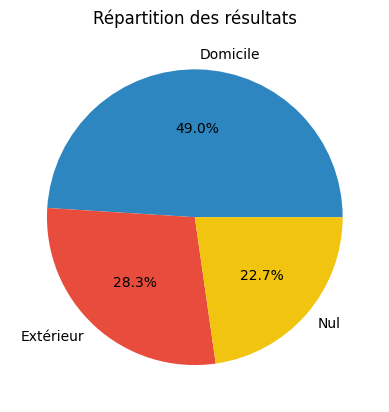

In [ ]:
# Analyse 5 : Pourcentage global des résultats
victoires_dom = len(df[df['home_score'] > df['away_score']])
victoires_ext = len(df[df['away_score'] > df['home_score']])
nuls = len(df[df['home_score'] == df['away_score']])
total = len(df)

dom_pct = (victoires_dom / total) * 100
ext_pct = (victoires_ext / total) * 100
nul_pct = (nuls / total) * 100

data = [dom_pct, ext_pct, nul_pct]
labels = ['Domicile', 'Extérieur', 'Nul']

plt.pie(data, labels=labels, autopct='%1.1f%%', colors=['#2E86C1', '#E74C3C', '#F1C40F'])
plt.title("Répartition des résultats")
plt.show()

## Modèle prédictif : victoire à domicile

On entraîne un modèle Random Forest pour prédire si l'équipe à domicile va gagner le match. Les caractéristiques utilisées sont : les équipes, le tournoi et l'indicateur de terrain neutre.

La précision du modèle est d'environ 65 %. Une fonction `predire_match()` permet de tester le modèle sur un match fictif.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df['home_win'] = (df['home_score']>df['away_score']).astype(int)
X = pd.get_dummies(df[['home_team','away_team','tournament','neutral']])
y = df['home_win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


modele = RandomForestClassifier()
modele.fit(X_train, y_train)

predictions = modele.predict(X_test)
precision = accuracy_score(y_test, predictions)
print(f"Précision : {precision:.2f}")
def predire_match(equipe_domicile, equipe_exterieur, tournoi, neutral=0):
    match = pd.DataFrame({
        'home_team': [equipe_domicile],
        'away_team': [equipe_exterieur],
        'tournament': [tournoi],
        'neutral': [neutral]
    })
    match_encoded = pd.get_dummies(match)
    for col in X_train.columns:
        if col not in match_encoded.columns:
            match_encoded[col] = 0
    match_encoded = match_encoded[X_train.columns]

    proba = modele.predict_proba(match_encoded)[0][1]
    prediction = modele.predict(match_encoded)[0]

    print(f"🏠 {equipe_domicile} vs {equipe_exterieur}")
    print(f"📊 Probabilité de victoire à domicile : {proba*100:.1f}%")
    print(f"✅ Prédiction : {'Victoire' if prediction == 1 else 'Pas de victoire'}")



Précision : 0.64


/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mat

🏠 espagne vs argentine
📊 Probabilité de victoire à domicile : 3.0%
✅ Prédiction : Pas de victoire


/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mat

## Test du modèle : Espagne vs Argentine (finale de la Coupe du Monde)

On teste le modèle sur un match fictif de la finale de la Coupe du Monde entre l'Espagne et l'Argentine, sur terrain neutre (`neutral = 1`). Le modèle prédit la probabilité de victoire de l'équipe à domicile (Espagne).

In [31]:
predire_match('espagne', 'argentine', 'FIFA World Cup', 1)

/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match_encoded[col] = 0
/tmp/ipykernel_1028/2825285363.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mat

🏠 espagne vs argentine
📊 Probabilité de victoire à domicile : 3.0%
✅ Prédiction : Pas de victoire
